## Gauss-Seidel method 

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


In [2]:
def compute_divergence(grad_x, grad_y):
    """Обчислення дивергенції градієнтного поля."""
    # div = d(grad_x)/dx + d(grad_y)/dy
    # Використовуємо зворотні різниці для дивергенції, якщо для градієнтів бралися прямі
    dx = grad_x - np.roll(grad_x, 1, axis=1)
    dy = grad_y - np.roll(grad_y, 1, axis=0)
    return dx + dy

def poisson_reconstruct_seidel(target_img, div, max_iter=500, tolerance=1e-4):
    """Відновлення одного каналу методом Гаусса-Зейделя з умовами Діріхле."""
    h, w = target_img.shape
    # Ініціалізуємо матрицю початковим зображенням (границі залишаються фіксованими)
    I = target_img.copy().astype(np.float64)
    
    for _ in range(max_iter):
        I_old = I.copy()
        # Внутрішні пікселі обробляємо послідовно
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                I[y, x] = 0.25 * (I[y, x+1] + I[y, x-1] + I[y+1, x] + I[y-1, x] - div[y, x])
                
        # Перевірка збіжності
        if np.max(np.abs(I - I_old)) < tolerance:
            break
            
    return np.clip(I, 0, 255).astype(np.uint8)

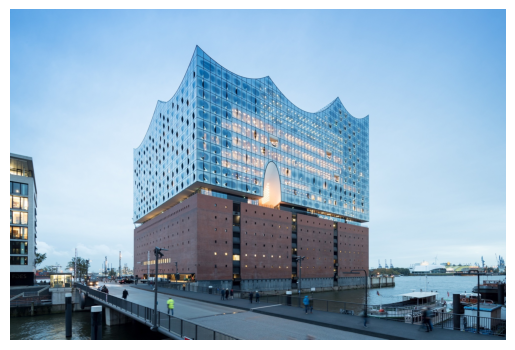

In [7]:
image1 = cv2.imread("data/Gamburg_philarmonie_on_Elbe.jpg")
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
plt.imshow(image1)
plt.axis("off")
plt.show()

In [18]:
# Quick code snippet to add Gaussian Noise
noise_image1 = np.random.normal(0, 50, image1.shape).astype(np.float64)
noisy_image1 = np.clip(image1.astype(np.float64) + noise_image1, 0, 255).astype(np.uint8)

TypeError: subplot() takes 1 or 3 positional arguments but 0 were given

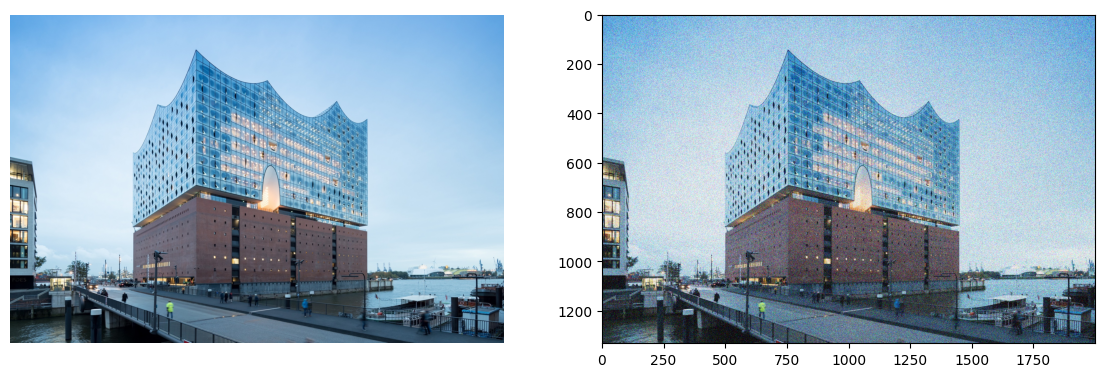

In [20]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(image1)
plt.subplot(122), plt.imshow(noisy_image1)

plt.subplot(121).axis("off")
plt.Subplot(122).title("Gaussian noisied")
plt.subplot(122).axis("off")

plt.show()